In [2]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from collections import OrderedDict
# ====================================================
# 1. Global config
# ====================================================
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 1337

root_dir = Path("chest_xray")
train_dir = root_dir / "train"           # NORMAL / PNEUMONIA(/bacteria,virus)
test_dir  = root_dir / "test"            # NORMAL / PNEUMONIA(/bacteria,virus)
train_pneu_dir = train_dir / "PNEUMONIA" # bacteria / virus
test_pneu_dir  = test_dir / "PNEUMONIA"  # bacteria / virus

AUTOTUNE = tf.data.AUTOTUNE

2025-12-10 22:39:04.612118: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# ====================================================
# 2. Preprocess + prepare helper
# ====================================================
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def prepare(ds, shuffle=False, repeat=False):
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    if repeat:
        ds = ds.repeat()
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



In [4]:
# ====================================================
# 3. Task A1: NORMAL vs PNEUMONIA
#    - use train/ (NORMAL, PNEUMONIA)
#    - test/ as fixed test set
#    - 10% of train used as validation
# ====================================================
# Load full training (unbatched) and test
train_full_A1 = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A1 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A1 classes:", train_full_A1.class_names)  # ['NORMAL', 'PNEUMONIA']

total_train_A1 = train_full_A1.cardinality().numpy()
val_size_A1 = int(0.10 * total_train_A1)
train_size_A1 = total_train_A1 - val_size_A1

train_raw_A1 = train_full_A1.take(train_size_A1)
val_raw_A1   = train_full_A1.skip(train_size_A1)

# --- A1 subsets ---
total_train_A1 = train_raw_A1.cardinality().numpy()

def make_A1_subset(fraction):
    n = int(total_train_A1 * fraction)
    subset_raw = train_raw_A1.take(n)
    return prepare(subset_raw, shuffle=True)

train_A1_10  = make_A1_subset(0.10)
train_A1_25  = make_A1_subset(0.25)
train_A1_50  = make_A1_subset(0.50)
train_A1_100 = prepare(train_raw_A1, shuffle=True)  # full pool

val_A1 = prepare(val_raw_A1)
test_A1 = prepare(test_raw_A1)



Found 5232 files belonging to 2 classes.


2025-12-10 22:39:08.185460: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 22:39:08.280111: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:27:00.0, compute capability: 7.0


Found 624 files belonging to 2 classes.
A1 classes: ['NORMAL', 'PNEUMONIA']


In [5]:
# ====================================================
# 4. Task A2: BACTERIA vs VIRUS (pneumonia only)
#    - use train/PNEUMONIA (bacteria, virus)
#    - test/PNEUMONIA as fixed test
#    - 10% of pneumonia-train used as validation
# ====================================================
train_full_A2 = tf.keras.utils.image_dataset_from_directory(
    train_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw_A2 = tf.keras.utils.image_dataset_from_directory(
    test_pneu_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=False,
    seed=SEED,
    batch_size=None,
)

print("A2 classes:", train_full_A2.class_names)  # ['bacteria', 'virus']

total_train_A2 = train_full_A2.cardinality().numpy()
val_size_A2 = int(0.10 * total_train_A2)
train_size_A2 = total_train_A2 - val_size_A2

train_raw_A2 = train_full_A2.take(train_size_A2)
val_raw_A2   = train_full_A2.skip(train_size_A2)

# --- A2 subsets ---
total_train_A2 = train_raw_A2.cardinality().numpy()

def make_A2_subset(fraction):
    n = int(total_train_A2 * fraction)
    subset_raw = train_raw_A2.take(n)
    return prepare(subset_raw, shuffle=True)

train_A2_10  = make_A2_subset(0.10)
train_A2_25  = make_A2_subset(0.25)
train_A2_50  = make_A2_subset(0.50)
train_A2_100 = prepare(train_raw_A2, shuffle=True)

val_A2 = prepare(val_raw_A2, repeat=True)
test_A2 = prepare(test_raw_A2)

val_steps_A2 = max(1, val_raw_A2.cardinality().numpy() // BATCH_SIZE)




Found 3883 files belonging to 2 classes.
Found 390 files belonging to 2 classes.
A2 classes: ['bacteria', 'virus']


In [12]:
# ====================================================
# Model C: Partial Fine-Tuning
# ====================================================
def make_backbone_C():
    # same backbone as B
    return tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
        pooling=None
    )

def make_classifier_C(num_classes, modelB_weights_path, unfreeze_last_n=20):
    backbone = make_backbone_C()
    backbone.trainable = False  

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    modelC = tf.keras.Model(inputs, outputs)

    modelC.load_weights(modelB_weights_path)

    for layer in backbone.layers[-unfreeze_last_n:]:
        layer.trainable = True

    modelC.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelC


In [19]:


# ====================================================
# 6C. Train Model C1 (NORMAL vs PNEUMONIA, Partial Fine-Tuning)
# ====================================================
EPOCHS = 20

c1_subsets = {
    "10%": train_A1_10,
    "25%": train_A1_25,
    "50%": train_A1_50,
    "100%": train_A1_100,
}

histories_C1 = {}
tests_C1 = {}
models_C1 = OrderedDict()


B1_weight_paths = {
    "10%": "B1_10%.h5",
    "25%": "B1_25%.h5",
    "50%": "B1_50%.h5",
    "100%": "B1_100%.h5",
}

for name, train_ds in c1_subsets.items():
    print(f"\n=== C1 (Partial Fine-Tune MobileNetV2) training on {name} of pool ===")

    
    model = make_classifier_C(
        num_classes=2,
        modelB_weights_path=B1_weight_paths[name],
        unfreeze_last_n=20,  
    )

    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A1,
    )

    histories_C1[name] = history.history
    tests_C1[name] = model.evaluate(test_A1, return_dict=True)
    models_C1[name] = model

print("C1 test metrics per subset:", tests_C1)



=== C1 (Partial Fine-Tune MobileNetV2) training on 10% of pool ===
Epoch 1/20
15/15 [==============================] - 15s 747ms/step - loss: 0.0987 - accuracy: 0.9766 - val_loss: 0.1126 - val_accuracy: 0.9656
Epoch 2/20
15/15 [==============================] - 12s 647ms/step - loss: 0.1342 - accuracy: 0.9426 - val_loss: 0.1295 - val_accuracy: 0.9541
Epoch 3/20
15/15 [==============================] - 11s 638ms/step - loss: 0.1153 - accuracy: 0.9660 - val_loss: 0.1274 - val_accuracy: 0.9579
Epoch 4/20
15/15 [==============================] - 11s 633ms/step - loss: 0.1093 - accuracy: 0.9660 - val_loss: 0.1193 - val_accuracy: 0.9656
Epoch 5/20
15/15 [==============================] - 11s 638ms/step - loss: 0.1059 - accuracy: 0.9596 - val_loss: 0.1113 - val_accuracy: 0.9694
Epoch 6/20
15/15 [==============================] - 11s 641ms/step - loss: 0.1107 - accuracy: 0.9532 - val_loss: 0.1152 - val_accuracy: 0.9560
Epoch 7/20
15/15 [==============================] - 11s 633ms/step - loss:

In [16]:
# ====================================================
# 7C. Train Model C2 (BACTERIA vs VIRUS, Partial Fine-Tuning)
# ====================================================
EPOCHS = 20

c2_subsets = {
    "10%": train_A2_10,
    "25%": train_A2_25,
    "50%": train_A2_50,
    "100%": train_A2_100,
}

histories_C2 = {}
tests_C2 = {}
models_C2 = OrderedDict()

B2_weight_paths = {
    "10%": "B2_10%.h5",
    "25%": "B2_25%.h5",
    "50%": "B2_50%.h5",
    "100%": "B2_100%.h5",
}

for name, train_ds in c2_subsets.items():
    print(f"\n=== C2 (Partial Fine-Tune MobileNetV2) training on {name} of pool ===")

    model = make_classifier_C(
        num_classes=2,
        modelB_weights_path=B2_weight_paths[name],
        unfreeze_last_n=20,   
    )


    history = model.fit(
        train_ds,
        epochs=EPOCHS,
        validation_data=val_A2,
        validation_steps=val_steps_A2,  
    )

    histories_C2[name] = history.history
    tests_C2[name] = model.evaluate(test_A2, return_dict=True)
    models_C2[name] = model

print("C2 test metrics per subset:", tests_C2)



=== C2 (Partial Fine-Tune MobileNetV2) training on 10% of pool ===
Epoch 1/20


2025-12-03 12:22:25.499773: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8401
2025-12-03 12:22:26.464627: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x55b345e29610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-03 12:22:26.464665: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): Tesla V100S-PCIE-32GB, Compute Capability 7.0
2025-12-03 12:22:26.469786: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-03 12:22:26.570675: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


11/11 [==============================] - 10s 529ms/step - loss: 0.5059 - accuracy: 0.7479 - val_loss: 0.6025 - val_accuracy: 0.7083
Epoch 2/20
11/11 [==============================] - 6s 433ms/step - loss: 0.5083 - accuracy: 0.7564 - val_loss: 0.5346 - val_accuracy: 0.7292
Epoch 3/20
11/11 [==============================] - 5s 394ms/step - loss: 0.5189 - accuracy: 0.7650 - val_loss: 0.5401 - val_accuracy: 0.7214
Epoch 4/20
11/11 [==============================] - 5s 401ms/step - loss: 0.5341 - accuracy: 0.7421 - val_loss: 0.5461 - val_accuracy: 0.7214
Epoch 5/20
11/11 [==============================] - 5s 408ms/step - loss: 0.4730 - accuracy: 0.7708 - val_loss: 0.4800 - val_accuracy: 0.7760
Epoch 6/20
11/11 [==============================] - 6s 411ms/step - loss: 0.4992 - accuracy: 0.7622 - val_loss: 0.5057 - val_accuracy: 0.7786
Epoch 7/20
11/11 [==============================] - 5s 407ms/step - loss: 0.5058 - accuracy: 0.7708 - val_loss: 0.5274 - val_accuracy: 0.7318
Epoch 8/20
11/11

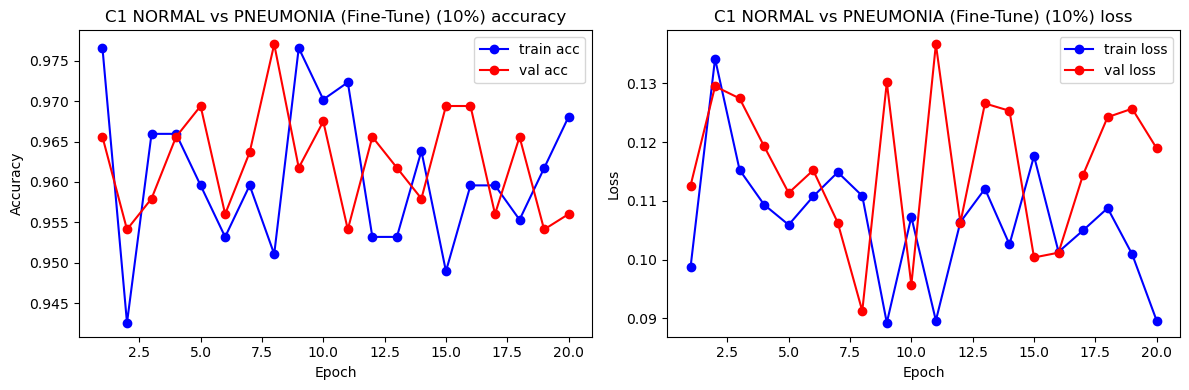

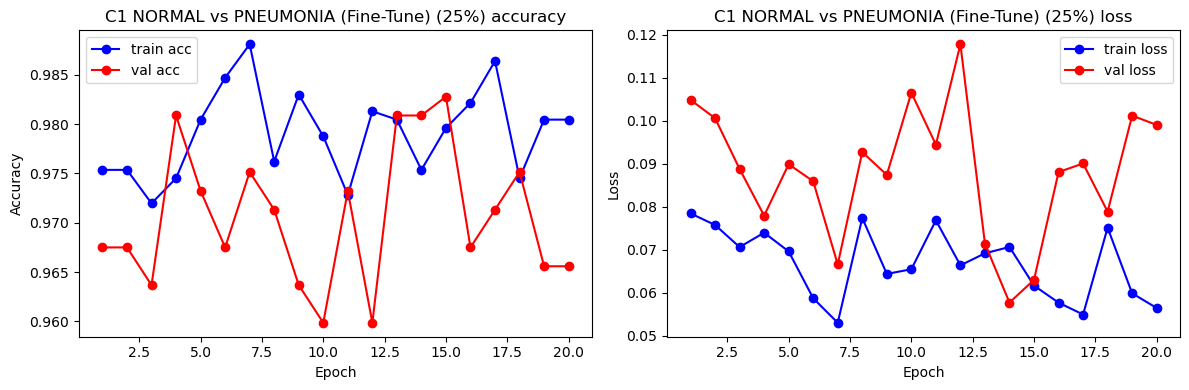

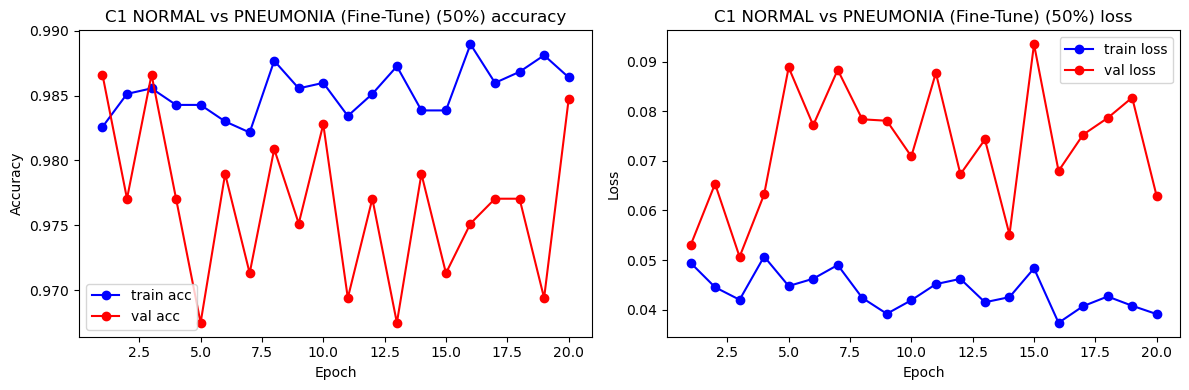

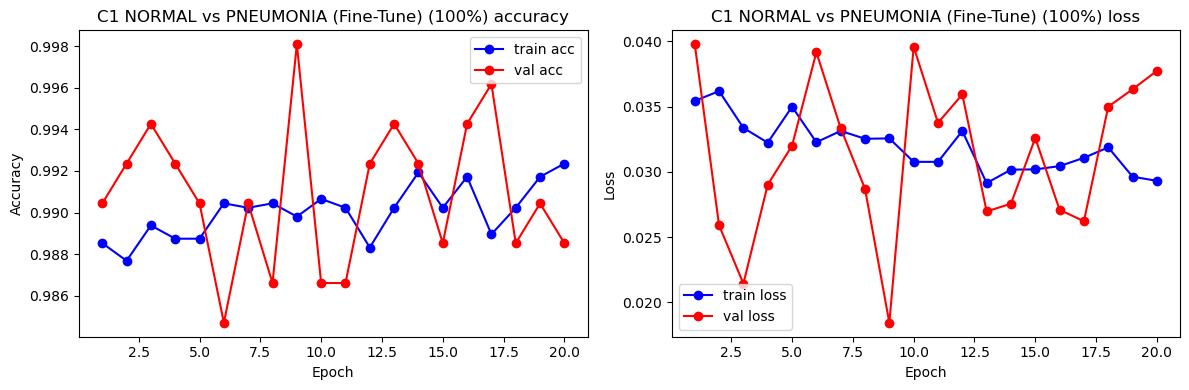

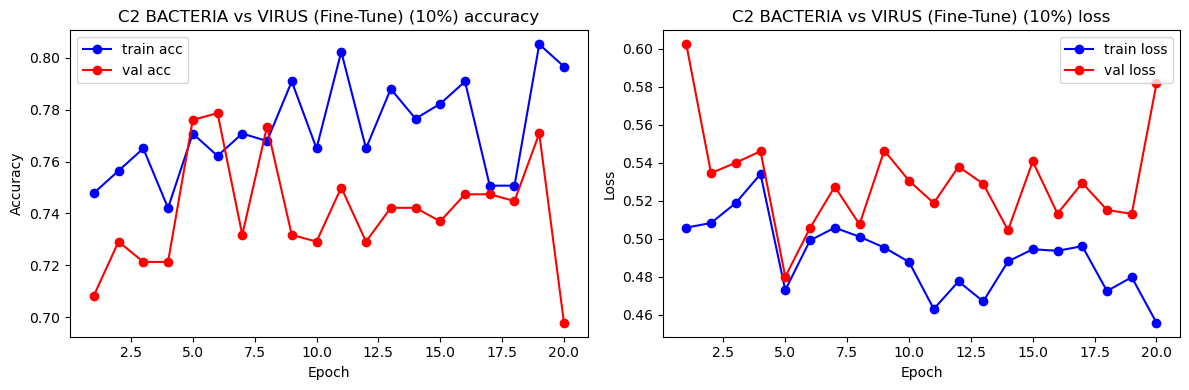

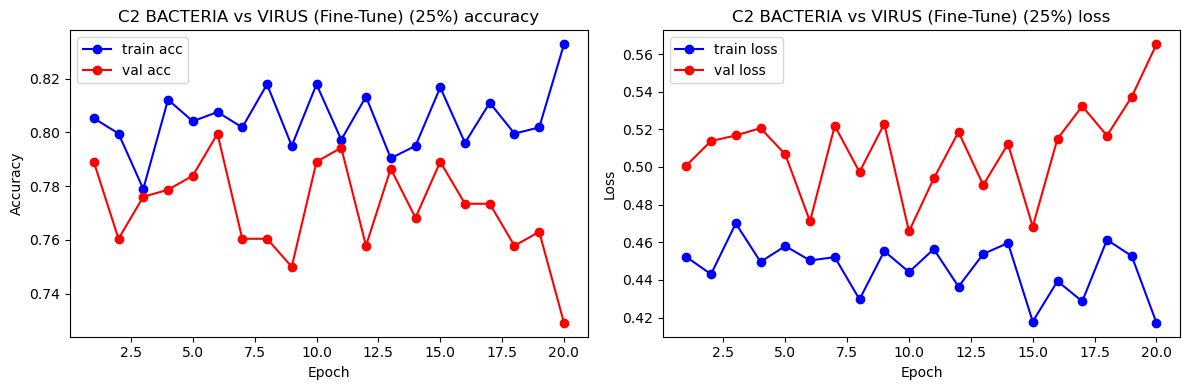

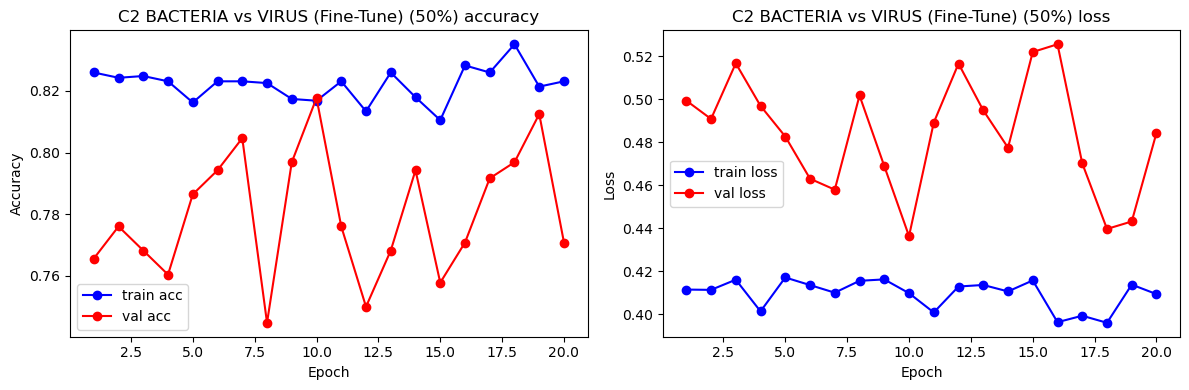

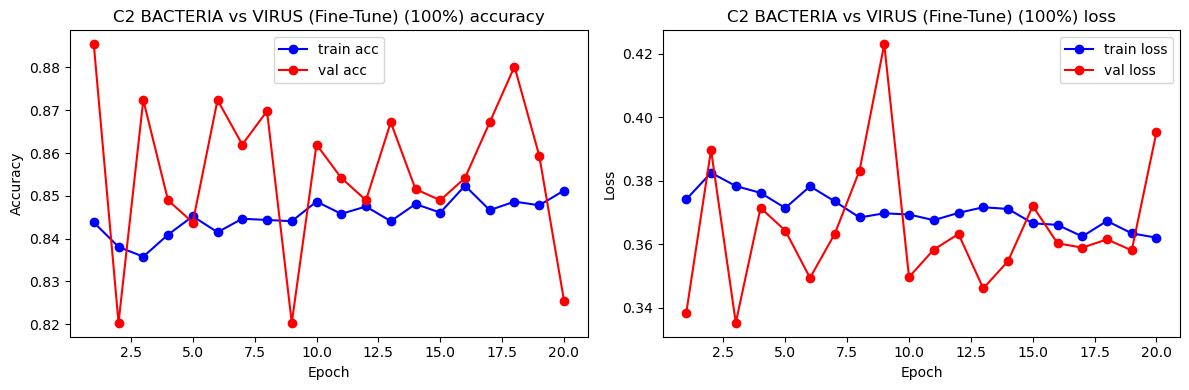

In [20]:
# ====================================================
# Plot histories for all subsets
# ====================================================

# small wrapper so plot_history can use .history like a Keras History object
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

# existing plotting function (unchanged)
def plot_history(history, title_prefix="Model"):
    acc = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss = history.history.get("loss", [])
    val_loss = history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if acc:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if val_acc:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if loss:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if val_loss:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ====================================================
# Plot C1 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_C1.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"C1 NORMAL vs PNEUMONIA (Fine-Tune) ({frac})"
    )
# ====================================================
# Plot C2 (Frozen MobileNetV2) histories
# ====================================================
for frac, hist_dict in histories_C2.items():
    plot_history(
        HistoryWrapper(hist_dict),
        title_prefix=f"C2 BACTERIA vs VIRUS (Fine-Tune) ({frac})"
    )


In [2]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def eval_with_confusion(model, test_ds, class_names, title="Model"):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        preds_labels = np.argmax(preds, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    print(f"\n{title} - Confusion matrix")
    print(cm)

    print(f"\n{title} - Classification report")
    print(classification_report(y_true, y_pred, target_names=class_names))

In [1]:
class_names_A1 = ["NORMAL", "PNEUMONIA"]
class_names_A2 = ["BACTERIA", "VIRUS"]

# C1: NORMAL vs PNEUMONIA (Frozen Backbone)
for name, model in models_C1.items():
    eval_with_confusion(
        model,
        test_A1,
        class_names_A1,
        title=f"C1 Frozen ({name} train pool)"
    )

# C2: BACTERIA vs VIRUS (Frozen Backbone)
for name, model in models_C2.items():
    eval_with_confusion(
        model,
        test_A2,
        class_names_A2,
        title=f"C2 Frozen ({name} train pool)"
    )


NameError: name 'models_C1' is not defined